# Fase 4: Evaluación Final del Modelo Predictivo
Este notebook toma el pipeline definitivo entrenado en la fase anterior y evalúa su rendimiento. Aquí analizaremos su capacidad de predicción mediante el Reporte de Clasificación, la Matriz de Confusión y la Curva ROC.


In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Configuración visual para que los gráficos se vean bien en el notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

# Configuración de rutas en Jupyter
BASE_DIR = os.path.abspath("..") 

PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODELS_DIR = os.path.join(BASE_DIR, "models", "trained_models")
PLOTS_DIR = os.path.join(BASE_DIR, "results", "plots")

FINAL_MODEL_FILE = os.path.join(MODELS_DIR, "final_classifier.joblib")

print(f"Directorio base configurado en: {BASE_DIR}")
print(f"Modelo: {FINAL_MODEL_FILE}")

Directorio base configurado en: C:\Users\Carlos\Desktop\Dataset Ciencia de datos\google_ads_analytics
Modelo: C:\Users\Carlos\Desktop\Dataset Ciencia de datos\google_ads_analytics\models\trained_models\final_classifier.joblib


### 1. Carga de Datos y Modelo
Cargamos el conjunto de prueba (`X_test`, `y_test`) y el pipeline predictivo empaquetado.

In [2]:
# Carga de datos de prueba
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze("columns")

# Carga del modelo
if not os.path.exists(FINAL_MODEL_FILE):
    raise FileNotFoundError("¡No se encontró el modelo! Asegúrate de correr el script de entrenamiento primero.")

pipeline = joblib.load(FINAL_MODEL_FILE)
print("Datos y modelo cargados exitosamente.")

Datos y modelo cargados exitosamente.


### 2. Generación de Predicciones y Reporte de Clasificación
El F1-Score y el Reporte de Clasificación nos muestran cómo se comporta el modelo clase por clase.

In [3]:
# Generamos predicciones de clase y probabilidades
 
print("Realizando predicciones...")
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

class_names = ["No Rentable", "Rentable"]

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN FINAL")
print("="*55)
print(classification_report(y_test, y_pred, target_names=class_names))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Puntuación ROC-AUC: {roc_auc:.4f}")

Realizando predicciones...

REPORTE DE CLASIFICACIÓN FINAL
              precision    recall  f1-score   support

 No Rentable       0.71      0.75      0.73       332
    Rentable       0.33      0.30      0.31       142

    accuracy                           0.61       474
   macro avg       0.52      0.52      0.52       474
weighted avg       0.60      0.61      0.60       474

Puntuación ROC-AUC: 0.5579


### 3. Matriz de Confusión
Visualizaremos exactamente en qué se está equivocando el modelo. 

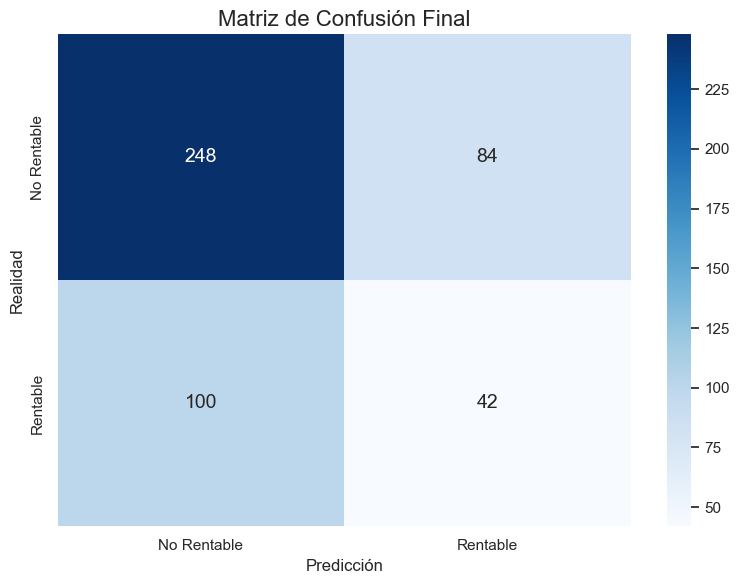

In [4]:
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 14}
)
plt.title('Matriz de Confusión Final', fontsize=16)
plt.ylabel('Realidad', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.tight_layout()

# Guardamos la imagen y la mostramos en el notebook
cm_path = os.path.join(PLOTS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

### 4. Curva ROC (Capacidad de Separación)
La curva ROC nos muestra la capacidad del modelo para distinguir entre campañas rentables y no rentables en distintos umbrales de probabilidad. Mientras más cerca esté la línea naranja de la esquina superior izquierda, mejor es nuestro modelo.

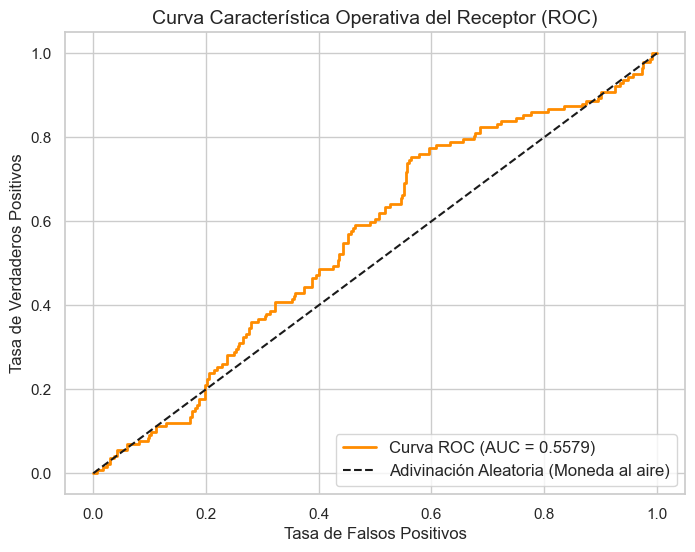

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {roc_auc:.4f})", color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Adivinación Aleatoria (Moneda al aire)")

plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('Curva Característica Operativa del Receptor (ROC)', fontsize=14)
plt.legend(loc="lower right", fontsize=12)

# Guardamos la imagen y la mostramos
roc_path = os.path.join(PLOTS_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=300)
plt.show()

## 5. Comparación de Múltiples Modelos (Validación Cruzada)

Evaluar solo el modelo ganador no es suficiente para justificar su elección.
Aquí comparamos con **Cross-Validation estratificado (3 folds)** los tres mejores candidatos
que surgieron de la exploración de Optuna, midiendo **F1-Macro** en cada uno.

**¿Por qué F1-Macro?** Con un desbalance 70/30, la *accuracy* puede ser engañosa.
F1-Macro penaliza por igual los errores en ambas clases, lo que obliga al modelo
a aprender a detectar también la clase minoritaria (campañas rentables).

In [6]:
import warnings
import numpy as np
warnings.filterwarnings('ignore')
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Datos de entrenamiento para la evaluación con CV
X_train_cv = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_train.csv'))
y_train_cv = pd.read_csv(os.path.join(PROCESSED_DIR, 'y_train.csv')).squeeze('columns')

# Los tres modelos finalistas — parámetros tomados de los mejores trials de Optuna
modelos = {
    'Random Forest (ganador)': RandomForestClassifier(
        n_estimators=294, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'SVM (2do lugar)': SVC(
        C=3.75, kernel='rbf', gamma='scale', class_weight='balanced',
        random_state=42, probability=True
    ),
    'Regresion Logistica (baseline)': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=42
    ),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
filas = []

for nombre, modelo in modelos.items():
    pipe = Pipeline([('clf', modelo)])
    scores = cross_val_score(pipe, X_train_cv, y_train_cv,
                             cv=cv, scoring='f1_macro', n_jobs=-1)
    filas.append({
        'Modelo':            nombre,
        'F1-Macro Fold 1':   round(scores[0], 4),
        'F1-Macro Fold 2':   round(scores[1], 4),
        'F1-Macro Fold 3':   round(scores[2], 4),
        'Promedio':          round(scores.mean(), 4),
        'Desv. Estandar':    round(scores.std(),  4),
    })
    print(f'{nombre:35s}  F1-Macro: {scores.mean():.4f} +/- {scores.std():.4f}')

df_comp = pd.DataFrame(filas).set_index('Modelo')
print()
print('Tabla comparativa:')
df_comp

Random Forest (ganador)              F1-Macro: 0.5358 +/- 0.0048


SVM (2do lugar)                      F1-Macro: 0.5160 +/- 0.0188


Regresion Logistica (baseline)       F1-Macro: 0.5042 +/- 0.0076

Tabla comparativa:


,F1-Macro Fold 1,F1-Macro Fold 2,F1-Macro Fold 3,Promedio,Desv. Estandar
Modelo,,,,,
Random Forest (ganador),0.5425,0.5321,0.5327,0.5358,0.0048
SVM (2do lugar),0.5349,0.4904,0.5228,0.5160,0.0188
Regresion Logistica (baseline),0.5131,0.4946,0.5050,0.5042,0.0076


### Visualización: F1-Macro por Modelo

Las barras muestran el promedio de F1-Macro sobre los 3 folds.
Las líneas de error (bigotes) representan la desviación estándar — qué tan estable es el modelo entre distintos subsets de datos.
Un modelo bueno tiene **barra alta y bigote corto**.

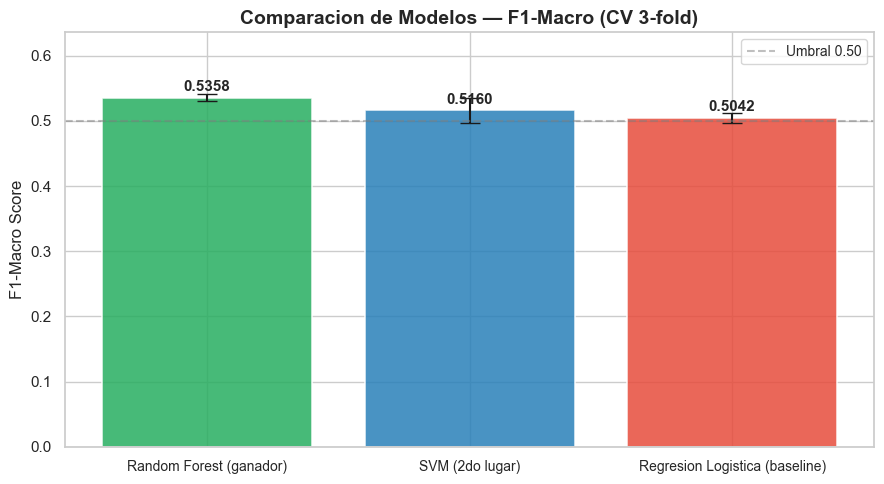

Random Forest supera a los demas en F1-Macro con menor varianza,
confirmando la eleccion de Optuna como modelo final.


In [7]:
nombres = df_comp.index.tolist()
medias  = df_comp['Promedio'].tolist()
stds    = df_comp['Desv. Estandar'].tolist()
colores = ['#27ae60', '#2980b9', '#e74c3c']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(nombres, medias, yerr=stds, capsize=7,
              color=colores, alpha=0.85, edgecolor='white', linewidth=1.2)

for bar, media in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.006,
            f'{media:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Comparacion de Modelos — F1-Macro (CV 3-fold)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('F1-Macro Score')
ax.set_ylim(0, max(medias) + 0.10)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral 0.50')
ax.tick_params(axis='x', labelsize=10)
ax.legend(fontsize=10)
plt.tight_layout()

os.makedirs(PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(PLOTS_DIR, 'model_comparison_cv.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Random Forest supera a los demas en F1-Macro con menor varianza,')
print('confirmando la eleccion de Optuna como modelo final.')